# PSAT Package Week 2 
시계열자료분석팀 2020311350 강철석

# Chapter1 : SQL 쿼리 입문

## 문제1. 
Sqlite3 패키지를 설치하고 불러온 후,database.db에 연결해주세요.

In [3]:
import sqlite3
print(sqlite3.version)

2.6.0


In [4]:
con = sqlite3.connect("database.db")
print(type(con))

<class 'sqlite3.Connection'>


## 문제2. 
Database,Table,Query가 무엇인지 간략하게 설명해주세요.

- Database: 데이터를 정리하여 보관하고 있는 저장소
- Table: 데이터가 저장되어있는 표, Entity
- Query: 데이터베이스에 정보를 요청하는 것으로 관계형 데이터베이스에서 사용하는 표준 질의언어



## 문제3. 
data1.csv,data2.csv를 불러와 database.db에 각각 may_comm_data,april_comm_data라는 이름으로 저장해주세요.

In [5]:
import pandas as pd
# df1 = pd.read_excel("data/data1.xlsx")
# df2 = pd.read_excel("data/data2.xlsx")

# df1.to_csv("data/data1.csv", index=False)
# df2.to_csv("data/data2.csv", index=False)

df1 = pd.read_csv("data/data1.csv")
df2 = pd.read_csv("data/data2.csv")


In [6]:
df1.to_sql("may_comm_data", con, if_exists = 'replace')
df2.to_sql("april_comm_data", con, if_exists = 'replace')

10176

## 문제4.
지금부터 할 분석은 여러 자치구의 서비스 사용 분포에 대해 탐구하는 것입니다. <br> 
먼저SQL 쿼리에서 SELECT,FROM,WHERE,JOIN,UNION,CREATE가 무엇인지 각각 설명하여 주세요.

- SELECT: DML(데이터 조작어)의 일종으로 쿼리에 맞는 데이터를 추출한다.
- FROM: 다루고자하는 테이블 선택
- WHERE: SELECT 문에서 사용하는 조건문
- JOIN: 데이터를 결합하는 방식 중 하나로 테이블의 컬럼이 추가되는 형식으로 두 데이터를 연결한다. 두 테이블의 연결을 위해서는 하나 이상의 컬럼을 공유해야한다. 
- UNION: 데이터를 결합하는 방식 중 하나로 데이터가 추가되는 형식으로 두 데이터를 연결한다.
- CREATE: DDL(데이터 정의어)의 일종으로 테이블을 생성한다.

## 문제5.
행정동에 맞게 UNION할 수 있도록 SQL 쿼리를 작성하여 출력해주세요.<br>
- (조건1) “월” 파생변수를 생성하여 may_comm_data의 데이터는 5를,april_comm_data의 데이터는 4를 입력해주어야 합니다.
- (조건2) comm_data라는 통합된 테이블명으로 저장하셔야 합니다.
- (HINT)  conn.excute를 사용하면 쉽게 sql에서 CREATE를 사용하여 테이블을 생성할 수 있습니다.

In [7]:
cursor = con.cursor()

cursor.execute("ALTER TABLE april_comm_data ADD 월 INT NOT NULL DEFAULT 4")
cursor.execute("ALTER TABLE may_comm_data ADD 월 INT NOT NULL DEFAULT 5")

값 체크

In [8]:
readed_df_april = pd.read_sql("SELECT * FROM 'april_comm_data'", con)
readed_df_may = pd.read_sql("SELECT * FROM 'may_comm_data'", con)

display(readed_df_april.head(2))
display(readed_df_may.head(2))

,index,행정동코드,자치구,행정동,성별,연령대,총인구수,1인가구수,야간상주지 변경 미추정 인구 수,야간상주지 변경횟수 평균,...,배달_브랜드 서비스 사용일수,"배달_브랜드 서비스 사용일수: 4분위수, 25%","배달_브랜드 서비스 사용일수: 4분위수, 50%","배달_브랜드 서비스 사용일수: 4분위수, 75%",배달_식재료 서비스 사용 미추정 인구수,배달_식재료 서비스 사용일수,"배달_식재료 서비스 사용일수: 4분위수, 25%","배달_식재료 서비스 사용일수: 4분위수, 50%","배달_식재료 서비스 사용일수: 4분위수, 75%",월
0,0,1101053,종로구,사직동,1,20,209.0,65.56,0,2.51,...,2.83,1.67,1.67,3.33,204.20,1.67,1.67,1.67,1.67,4
1,1,1101053,종로구,사직동,1,25,336.0,111.25,0,2.06,...,3.00,1.67,3.33,5.00,333.27,1.67,1.67,1.67,1.67,4


,index,행정동코드,자치구,행정동,성별,연령대,총인구수,1인가구수,야간상주지 변경 미추정 인구 수,야간상주지 변경횟수 평균,...,배달_브랜드 서비스 사용일수,"배달_브랜드 서비스 사용일수: 4분위수, 25%","배달_브랜드 서비스 사용일수: 4분위수, 50%","배달_브랜드 서비스 사용일수: 4분위수, 75%",배달_식재료 서비스 사용 미추정 인구수,배달_식재료 서비스 사용일수,"배달_식재료 서비스 사용일수: 4분위수, 25%","배달_식재료 서비스 사용일수: 4분위수, 50%","배달_식재료 서비스 사용일수: 4분위수, 75%",월
0,0,1101053,종로구,사직동,1,20,209.0,65.56,0,2.51,...,2.83,1.67,1.67,3.33,204.20,1.67,1.67,1.67,1.67,5
1,1,1101053,종로구,사직동,1,25,336.0,111.25,0,2.06,...,3.00,1.67,3.33,5.00,333.27,1.67,1.67,1.67,1.67,5


In [45]:
cursor.execute("CREATE TABLE comm_data AS SELECT * FROM april_comm_data UNION ALL SELECT * FROM may_comm_data")
readed_df = pd.read_sql("SELECT * FROM 'comm_data'", con)
display(readed_df.head(3))
display(readed_df.tail(3))

,index,행정동코드,자치구,행정동,성별,연령대,총인구수,1인가구수,야간상주지 변경 미추정 인구 수,야간상주지 변경횟수 평균,...,배달_브랜드 서비스 사용일수,"배달_브랜드 서비스 사용일수: 4분위수, 25%","배달_브랜드 서비스 사용일수: 4분위수, 50%","배달_브랜드 서비스 사용일수: 4분위수, 75%",배달_식재료 서비스 사용 미추정 인구수,배달_식재료 서비스 사용일수,"배달_식재료 서비스 사용일수: 4분위수, 25%","배달_식재료 서비스 사용일수: 4분위수, 50%","배달_식재료 서비스 사용일수: 4분위수, 75%",월
0,0,1101053,종로구,사직동,1,20,209.0,65.56,0,2.51,...,2.83,1.67,1.67,3.33,204.20,1.67,1.67,1.67,1.67,4
1,1,1101053,종로구,사직동,1,25,336.0,111.25,0,2.06,...,3.00,1.67,3.33,5.00,333.27,1.67,1.67,1.67,1.67,4
2,2,1101053,종로구,사직동,1,30,416.0,141.28,0,1.91,...,2.70,1.67,1.67,3.33,410.00,1.67,1.67,1.67,1.67,4


,index,행정동코드,자치구,행정동,성별,연령대,총인구수,1인가구수,야간상주지 변경 미추정 인구 수,야간상주지 변경횟수 평균,...,배달_브랜드 서비스 사용일수,"배달_브랜드 서비스 사용일수: 4분위수, 25%","배달_브랜드 서비스 사용일수: 4분위수, 50%","배달_브랜드 서비스 사용일수: 4분위수, 75%",배달_식재료 서비스 사용 미추정 인구수,배달_식재료 서비스 사용일수,"배달_식재료 서비스 사용일수: 4분위수, 25%","배달_식재료 서비스 사용일수: 4분위수, 50%","배달_식재료 서비스 사용일수: 4분위수, 75%",월
20349,10173,1125074,강동구,길동,2,65,1854.0,333.17,0,1.39,...,2.78,1.67,1.67,5.00,1846.0,1.67,1.67,1.67,1.67,5
20350,10174,1125074,강동구,길동,2,70,1236.0,205.82,0,1.40,...,1.67,1.67,1.67,1.67,1234.0,1.67,1.67,1.67,1.67,5
20351,10175,1125074,강동구,길동,2,75,1570.0,645.99,0,1.37,...,2.50,1.67,1.67,1.67,1568.0,1.67,1.67,1.67,1.67,5


## 문제6. 
총인구수가 200 이상, 연령대가 60 이하인 경우만을 쿼리를 통해 필터링하여 출력해주세요.
- (HINT1) DELETE 쿼리를 사용하면 쉽게 sql에서 조건에 맞는 데이터를 제거할 수 있습니다.
- (HINT2) INSERT,UPDATE,DELETE는 conn.commit()을 통해 변경사항을 저장해주어야 합니다.

In [9]:
query= "DELETE FROM comm_data WHERE 총인구수 < 200 OR 연령대 > 60"
cursor.execute(query)
con.commit()

df_ = pd.read_sql("SELECT * FROM 'comm_data'", con)
print(df_.shape)

del df_

(15036, 145)


## 문제7. 
우리가 필요한 1인가구수, 연령대, 자치구, 행정동, 금융 서비스 사용일수, 쇼핑 서비스 사용일수, 
동영상/방송 서비스 사용일수, 유튜브 사용일수, 넷플릭스 사용일수, 배달 서비스 사용일수입니다.

해당 열만을 선택하여 df라는 이름의 PandasDataFrame으로 추출해주세요.
- (HINT1) pandas의 read_sql_query함수를 통해 쿼리를 보냄과 동시에 DataFrame을 반환받을 수 있습니다.
- (HINT2) 한국어 및 공백을 포함한 열의 경우 []로 감싸주어야 인식할 수 있습니다.

In [10]:
query = '''SELECT [1인가구수], [연령대], [자치구], [행정동], [금융 서비스 사용일수], 
    [쇼핑 서비스 사용일수], [동영상/방송 서비스 사용일수], [유튜브 사용일수], 
    [넷플릭스 사용일수], [배달 서비스 사용일수]  FROM comm_data'''

df = pd.read_sql_query(query, con)
df.shape

(15036, 10)

# Chapter2: Modeling&Analysis

## 문제1
이번 분석에서 사용할 패키지는 statsmodel,optuna,lightgbm,shap,seaborn,scikit-learn입니다.

해당 패키지를 설치한 후 불러와주세요.

In [12]:
import numpy as np
import statsmodels
import optuna
from optuna import trial, visualization
from optuna.samplers import TPESampler
import lightgbm as lgb
import shap
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## 문제2 
LGBM과 사용되는 파라미터에 대해 간단하게 설명해주세요.

#### LGBM: 

Gradient Boosting Decision Tree는 모든 Feature, Data의 Scan을 통해 Gradient가 측정되기 때문에 계산복잡도가 O(# of data * # of features)로 매우 높게 측정된다.

이를 해결하기 위해 LGBM은 Gradient based One-Side Sampling(GOSS)과 Exclusive Feature Bundling(EFB) 방식을 적용하였다.
- GOSS: Gradient를 기준으로 Instance를 정렬한 후 Down Sampling 
- EFB: Mutually Exclusive(동시에 0이 아닌 값을 갖지 않는 관계) 한 Feature를 Bundling 한다. 고차원의 데이터는 sparse하다는 가정 하에, 상호배타적인 변수들을 하나의 bucket으로 묶어서 Feature 수를 줄이는 방식


#### Parameters of LGBM:
- objective: 회귀 문제에서 regression, regression_l2, 분류 문제에서 binary, multiclass 등으로 설정이 가능하고 custom score 함수 또한 지정이 가능하다. 
- boosting: boosting 방식을 지정하며 default는 전통적인 gbdt이다. rf, dart 등의 option이 존재한다.
- num_iterations: number of boosting iterations로 default는 100이다. 내부적으로 LGBM은 Multi-Classification 문제에서 num_class * num_iterations 개의 Tree를 구축한다. 
- learning_rate: 학습률
- num_leaves: 전체 Tree의 Leaf 수
- device_type: cpu, gpu, cuda 등을 지정할 수 있다.
- seed: seed 
- max_depth: Tree의 최대 깊이
- min_data_in_leaf: Leaf가 가지는 최소 Record의 수
- early_stopping_round: Validation 결과가 개선되지 않으면 Early Stopping
- lambda: regularization 정규화

## 문제3
LGBM에 [1인가구수]를 label, [1인가구수, 자치구, 행정동]을 제외한 나머지 변수들을 feature로 하여 간단하게 모델링을 진행해 주세요.

Optuna: Automatic Hyperparameter Optimization Framework

- (조건1) 이번 주제분석에서는 optuna를 사용하여 하이퍼파라미터를 직접 튜닝하여 보겠습니다. 모델링에 앞서 마크다운 셀을 사용하여 optuna에 대해 간략하게 설명해주세요.
- (조건2) 작은 수의 trial에서는 TPEsampler 방식이 가장 성능이 좋다고 알려져있습니다.Sampler는 TPEsampler에 seed=42를 설정해준 후, 파라미터 범위는 아래와 같이 지정해주세요.
- (조건3) LightGBM을 fit할 때,early_stopping을 시도하고자 합니다. Stoppingrounds를 100으로 지정하고 optuna의 n_trials를 30으로 하여 튜닝을 시작해주세요.
- (조건4) 랜덤 시드는 42로, 8:2holdoutvalidation을 진행하여 성능이 평가되어야 합니다. 마지막에는 best params를 활용한 finaltestrmse까지 출력해주세요.

In [13]:
df.head()

,1인가구수,연령대,자치구,행정동,금융 서비스 사용일수,쇼핑 서비스 사용일수,동영상/방송 서비스 사용일수,유튜브 사용일수,넷플릭스 사용일수,배달 서비스 사용일수
0,65.56,20,종로구,사직동,121.90,118.90,48.65,0.25,-0.14,12.58
1,111.25,25,종로구,사직동,159.51,155.75,43.29,0.25,-0.20,13.58
2,141.28,30,종로구,사직동,167.58,166.56,47.70,0.18,-0.23,14.78
3,121.28,35,종로구,사직동,175.77,183.94,46.71,0.11,-0.27,15.24
4,110.54,40,종로구,사직동,167.40,182.47,45.43,0.00,-0.24,13.53


In [14]:
y = df["1인가구수"]
X = df.drop(["1인가구수", "자치구", "행정동"], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [81]:
def objective(trial):

    params = {
        "objective": "regression",
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 200),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-3, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-3, 10.0, log=True),
        'random_state': 42,
        "verbose": -1,
        }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], callbacks = [lgb.early_stopping(stopping_rounds=3)])
    rmse = mean_absolute_error(y_test, model.predict(X_test))
    
    return rmse

In [ ]:
sampler = TPESampler(seed=42)

study_lgb = optuna.create_study(direction="minimize", sampler=sampler)
study_lgb.optimize(objective, n_trials=100)

In [84]:
print(f"best mse: {study_lgb.best_value}")

best mse: 46.360207548284436


# 문제4 
LGBM의 plot_importance 함수를 사용하여 featureimportance를 시각화하여주세요.
- (조건) importance_type는 “gain”으로 지정하여 주고,gain이 무엇을 의미하는지 간략하게 설명해주세요.

In [86]:
trial = study_lgb.best_trial
trial_params = trial.params
final_lgb_model = lgb.LGBMRegressor(**trial_params)
final_lgb_model.fit(X_train, y_train)
final_lgb_pred = final_lgb_model.predict(X_test)

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

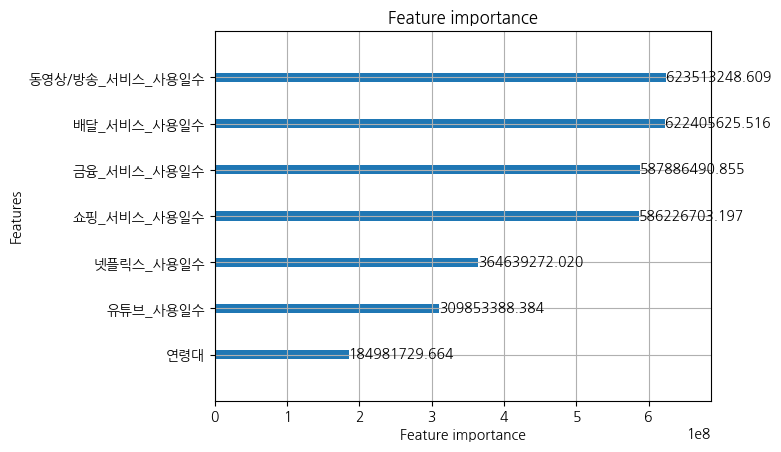

In [89]:
lgb.plot_importance(final_lgb_model, max_num_features=len(X_train.columns), importance_type='gain')

## 문제5. 
배달 서비스 사용일수와 쇼핑 서비스 사용일수가 1인가구수에 미치는 영향이 절대적이라고 생각하여,

나머지 변수를 다 제거한 후 두 변수 만을 입력 feature로 사용하기로 결정하였습니다.

이러한 결정에 어떠한 문제가 있는지 이유와 함께 자세히 설명해주세요.

(조건) 인과관계에 대한 언급을 반드시 넣어주세요.

> Feature Importance는 Feature Selection이 아니다. Full Model 학습 결과 모델에서 MSE를 낮추거나 빈번하게 분기 과정에서 사용하는 것일 뿐, 
> 
> Subset Model 내에서도 동일하게 높은 성능을 기대할 수는 없다. 

## 문제6.
ShapValue를 통해 변수의 영향력을 해석해보고자 합니다. 

먼저 Shapvalue가 무엇인지 자세하게 설명해주세요.

각 피쳐가 값을 예측하는데 기여한 정도를 계산하는 것이 shap value으로 한 피쳐가 예측을 얼마나 증가 혹은 감소시키는가를 계산한다.

예를 들어 f라는 모델을 구축했고 Height라는 feature에 대해 shap value를 계산하려 한다면, 전체 피쳐로 만들 수 있는 조합들에서 f(Height를 포함했을때) - f(Height를 포함하지 않았을 때) 들의 합으로 shap value를 구할 수 있다. 단, 예측값을 계산할 때 우리가 만든 함수의 조건부 기댓값을 이용한다.

E[f(x)]와 predicted f(x)는 일반적으로 다른 값을 가질텐데 이때 각 피쳐가 이 차이를 가져오는데 어떤 영향을 주었는지 계산하여 모델을 실제로 설명할 수 있게 된다.


## 문제7.
Shapvalue의 summaryplot과 forceplot을 사용하여 다음과 같이 shapvalue를 시각화하고 간단하게 해석해주세요.

> Shap Value 해석 시 Low와 High가 명확히 구분 되는 경우 해석이 쉽다.
> 
> 대표적으로 배달 서비스 사용일수는 값이 클수록 Shap Value도 커져 예측값을 크게 하는 방향으로 영향력을 행사하며, 값이 작을 때 예측값을 작게 한다.
> 
> 유튜브 사용일수 또한 이와 유사한 양상이지만 그 정도에서는 차이가 있다.
>  

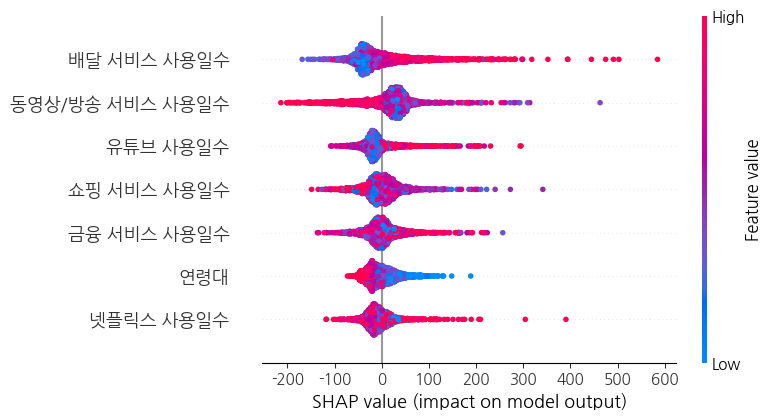

In [90]:
import shap

explainer = shap.TreeExplainer(final_lgb_model) 
shap_values = explainer.shap_values(X_test) 

shap.summary_plot(shap_values, X_test)

## 문제8.
이번에는 LinearRegression을 통해 모델링을 진행하고 해석해보겠습니다.

X_train,X_test,y_train, y_test로 8:2 validation을 진행한 후 X_train에 대해 상관관계 시각화를 진행해주세요.

<Axes: >

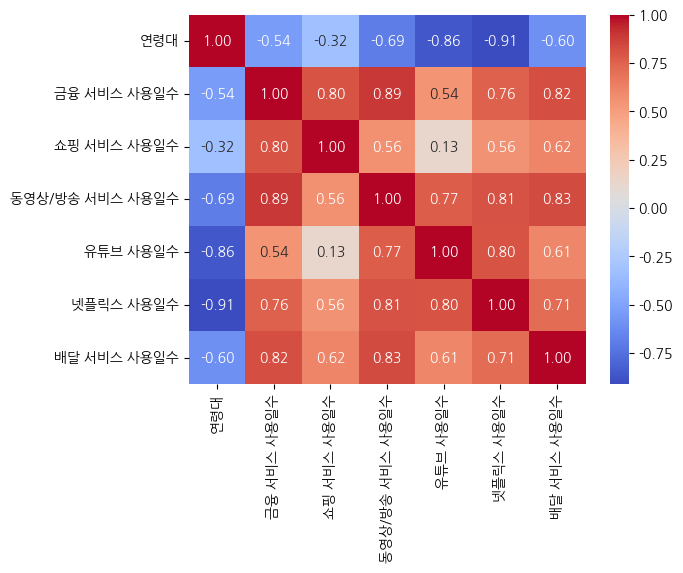

In [95]:
corr = X_train.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

## 문제9.
상관관계 분석과 직관에 의해 [금융 서비스 사용일수, 쇼핑 서비스 사용일수],[동영상/방송 서비스 사용일수, 유튜브 사용일수, 넷플릭스 사용일수]는 각각 하나의 지수로 통합하고자 합니다. 

X_train에 두 집합을 PCA하여 금융 관련 지수, 영상 관련 지수로 대체하고, 이를 X_train2로 저장해주세요.

In [96]:


fin_cols = ["금융 서비스 사용일수", "쇼핑 서비스 사용일수"]
vid_cols = ["동영상/방송 서비스 사용일수", "유튜브 사용일수", "넷플릭스 사용일수"]

PCA_fin = PCA(n_components=1)
X_train_fin = X_train[fin_cols]
scaler_fin = StandardScaler()
X_train_fin_scaeld = scaler_fin.fit_transform(X_train_fin)
X_train_fin_pca = PCA_fin.fit_transform(X_train_fin_scaeld)


scaler_vid = StandardScaler()
PCA_vid = PCA(n_components=1)
X_train_vid = X_train[vid_cols]
X_trian_vid_scaled = scaler_vid.fit_transform(X_train_vid)
X_train_vid_pca = PCA_vid.fit_transform(X_trian_vid_scaled)


X_train2 = X_train.copy()
X_train2.drop(fin_cols + vid_cols, axis=1, inplace=True)
X_train2["금융 관련 지수"] = X_train_fin_pca
X_train2["영상 관련 지수"] = X_train_vid_pca

display(X_train2.head())


,연령대,배달 서비스 사용일수,금융 관련 지수,영상 관련 지수
6307,55,11.96,43.724825,7.802708
4342,35,15.98,-43.929985,-8.539704
1068,45,12.69,-4.115808,-5.987454
9016,35,16.10,-50.340698,-10.849451
4800,30,13.80,-25.513627,-0.729638


## 문제10.
X_test에도 PCA를 적용하고 X_test2로 저장해주세요.(DataLeakage에 주의해주세요.)

In [97]:
X_test_fin = X_test[fin_cols]
X_test_fin_scaeld = scaler_fin.transform(X_test_fin)
X_test_fin_pca = PCA_fin.transform(X_test_fin_scaeld)


X_test_vid = X_test[vid_cols]
X_test_vid_scaled = scaler_vid.transform(X_test_vid)
X_test_vid_pca = PCA_vid.transform(X_test_vid_scaled)


X_test2 = X_test.copy()
X_test2.drop(fin_cols + vid_cols, axis=1, inplace=True)
X_test2["금융 관련 지수"] = X_test_fin_pca
X_test2["영상 관련 지수"] = X_test_vid_pca

display(X_test2.head())


,연령대,배달 서비스 사용일수,금융 관련 지수,영상 관련 지수
13309,35,14.19,-55.527026,-2.169005
12832,35,14.39,-63.624907,-13.100109
6393,35,16.25,-29.792808,-8.319755
4990,35,15.63,-35.658837,-13.178969
12460,20,11.59,28.218370,1.778629


## 문제11.
PCA를 진행한 경우와 진행하지 않은 경우 모두 OLS를 진행하고 coef를 해석하여 비교해주세요

> PCA를 하지 않았을 때 영상관련 변수들은 절대값이 큰 계수들은 가지며 금융 관련 변수들은 절대값이 작은 계수들을 가진다.
>
> 넷플릭스 사용 지수는 유의하지 않은 변수로 나타나고, 변수 스케일들로 인한 회귀 계수 차이가 큰 것으로 나타난다.
> 
> PCA 이후 영상 관련 지수는 차원 축소 이전과 마찬가지로 절대값이 큰 계수들은 가지며 금융 관련 변수 또한 절대값이 작은 계수들을 가진다.



#### 1. 모델 요약
- 종속 변수: 1인가구수

- 모델의 목표는 1인가구수에 영향을 미치는 요인을 설명하고 예측하는 것입니다.

- R-squared (결정 계수): 0.162

- 독립 변수들이 종속 변수의 변동성을 16.2% 설명합니다.

- F-statistic: 579.1, Prob (F-statistic): 0.00

> 모델 전체가 유의미하다는 것을 나타냅니다 (p-value < 0.05).

#### 2. 독립 변수들의 해석
 
각 변수의 회귀 계수(coef), t-값, p-값 등을 해석합니다.

**변수 별 계수(coef) 해석**
- 상수항 (const) : -261.87 모든 독립 변수가 0일 때, 1인가구수는 -261.87입니다.
- 연령대 : -3.25	연령대가 1 증가할 때, 1인가구수는 평균적으로 3.25 감소합니다. (p-value < 0.05)
- 배달 서비스 사용일수 : 	45.69	배달 서비스 사용일수가 1일 증가할 때, 1인가구수는 평균적으로 45.69 증가합니다. (p-value < 0.05)
- 금융 관련 지수 : 0.64	금융 관련 지수가 1 증가할 때, 1인가구수는 평균적으로 0.64 증가합니다. (p-value < 0.05)
- 영상 관련 지수 : 7.70	영상 관련 지수가 1 증가할 때, 1인가구수는 평균적으로 7.70 증가합니다. (p-value < 0.05)
- 모든 독립 변수의 p-value가 0.000으로 매우 유의미합니다.

In [98]:
import statsmodels.api as sm

# OLS with PCA
model_wi_pca = sm.OLS(y_train, sm.add_constant(X_train2)).fit()

# OLS without PCA
model_wo_pca = sm.OLS(y_train, sm.add_constant(X_train)).fit()

print(model_wi_pca.summary())
print(model_wo_pca.summary())

                            OLS Regression Results                            
Dep. Variable:                  1인가구수   R-squared:                       0.162
Model:                            OLS   Adj. R-squared:                  0.161
Method:                 Least Squares   F-statistic:                     579.1
Date:                Thu, 26 Sep 2024   Prob (F-statistic):               0.00
Time:                        19:44:23   Log-Likelihood:                -79516.
No. Observations:               12028   AIC:                         1.590e+05
Df Residuals:                   12023   BIC:                         1.591e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        -261.8689     17.867    -14.657      

# Chapter 3 : 분포 분석

## 문제1. 
이번 챕터에서는 연령대별, 자치구별 1인가구수를 비교해보고자 합니다.

이를 위해서는 JensonShannonDivergence(JSD)에 대한 지식이 선행되어야 합니다.

먼저 KLD와 JSD에 대해 수식과 함께 설명해주세요.


### KLD(Kullback-Leibler divergence):

두 확률분포의 차이를 계산하는 데에 사용하는 함수로 어떠한 확률분포 P가 있을 때, 샘플링 과정에서 그 분포를 근사적으로 표현하는 확률분포 Q를 P 대신 사용할 경우 엔트로피 변화를 의미한다.

$$
D_{\text{KL}}(P \parallel Q) = \sum_{x} P(x) \log\left(\frac{P(x)}{Q(x)}\right)
$$



### JSD(Jenson-Shannon divergence): 

M을 확률분포 p와 q의 평균이라 정의할 때, M과 P, M과 Q의 KL divergence를 각각 한번씩 구하고 이 값들을 평균 낸 값

$$
D_{\text{JS}}(P \parallel Q) = \frac{1}{2} D_{\text{KL}}(P \parallel M) + \frac{1}{2} D_{\text{KL}}(Q \parallel M)
$$

$$
where, M = \frac{1}{2}(P + Q)
$$


두 분포 모두 divergence의 개념으로 0에 가까울수록 두 분포가 유사함을 의미한다.

## 문제2. 
먼저, 연령대별 1인가구수를 간단하게 비교해보겠습니다.

df를이용하여 연령대에 따른 전체 지역의 1인가구수 평균을 아래와 같이 barplot으로 그려주세요.

- (HINT)pandas의 groupby를 사용하셔도 되고, SQL을통해 groupby를 진행하셔도 됩니다.
- (조건) 막대 그래프는 color= ‘skyblue’, width=3, 꺾은선 그래프는 color='r',linestyle='--',marker='o', xticks는 rotation=45로 설정해주세요.

In [110]:
df_pop_age = df.groupby("연령대")["1인가구수"].mean()


연령대
20    206.094195
25    267.386364
30    249.842038
35    201.307422
40    140.722598
45    131.432661
50    119.361902
55    118.081205
60    110.537461
Name: 1인가구수, dtype: float64

Text(0, 0.5, '1인가구수')

<Figure size 1000x500 with 0 Axes>

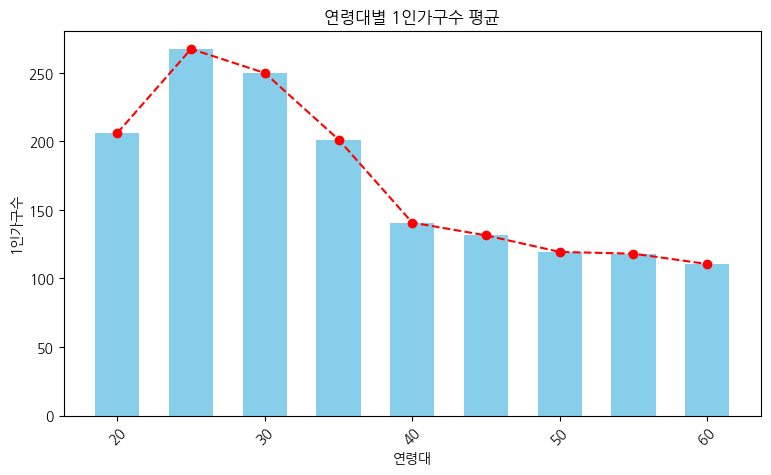

In [119]:
plt.figure(figsize=(10, 5))

plt.bar(x=df_pop_age.index, height=df_pop_age.values, width = 3, color = 'skyblue')
plt.plot(df_pop_age, linestyle = "--", marker='o', color='r')

plt.xticks(rotation=45)
plt.title("연령대별 1인가구수 평균")
plt.xlabel("연령대")
plt.ylabel("1인가구수")

## 문제3. 
전체적인 추이는 파악했지만, 우리는 자치구별 1인가구의 연령대 분포차이가 궁금합니다.

df의 1인가구수를 자치구, 연령대에 대해 groupby하여 df_final로 저장해주세요

In [140]:
df_final = df.groupby(["자치구", "연령대", ])["1인가구수"].sum()
display(df_final)

자치구  연령대
강남구  20     13151.20
     25     22902.70
     30     32815.88
     35     27312.50
     40     17323.48
              ...   
중랑구  40      9695.54
     45      9939.74
     50     11346.60
     55     11712.86
     60     10818.84
Name: 1인가구수, Length: 225, dtype: float64

## 문제4.
df_final을 자치구별 연령대에 따른 1인가구수로 시각화하여 한번에 꺾은선 그래프로 표현해주세요.

<Figure size 1000x3000 with 0 Axes>

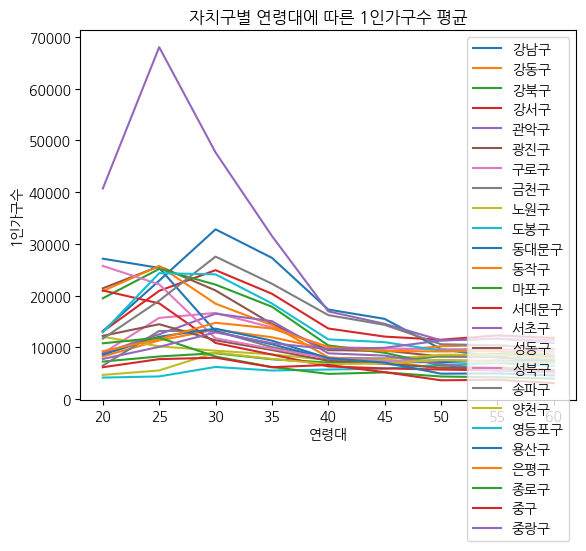

In [143]:
# plot the result
plt.figure(figsize=(10, 30))

df_unstack = df_final.unstack()
df_unstack.T.plot()
plt.title("자치구별 연령대에 따른 1인가구수 평균")
plt.xlabel("연령대")
plt.ylabel("1인가구수")
plt.legend(loc='upper right')

plt.show()


## 문제5. 
지금부터 우리는 종로구와 가장 비슷한 1인가구수 분포를 보이는 자치구와, 가장 다른 분포를 보이는 자치구를 계산하고자 합니다.

먼저 종로구와 은평구 간 연령대별 1인가구수 분포 JSD를 계산하는 코드를 작성해주세요.

- (HINT) JSD는 scipy.spatial.distance의 jensenshannon 함수를 통해 쉽게 구할 수 있습니다.

In [145]:
from scipy.spatial.distance import jensenshannon

dis = jensenshannon(df_final['종로구'], df_final['은평구'])

print(f"종로구와 은평구의 JS distance: {dis}")

종로구와 은평구의 JS distance: 0.12839777690062523


## 문제6. 
위의 코드를 종로구와 특정구 간 JSD를 계산할 수 있는 JSD_single 함수로 작성해주세요.

> 함수 In-Out 명세서<br> ­
-함수의 Input으로는 전체 [데이터프레임],관찰하고 싶은 [자치구명]이 필요합니다. <br>
-함수의 Output으로는 두 자치구간 JSD값이 반환되어야 합니다. 

In [146]:
def JSD_single(df, gu_name):
    """
        Fucntion to calculate JSD between a given gu and 종로구
    """

    dis = jensenshannon(df['종로구'], df[gu_name])
    return dis

## 문제7.
종로구를 제외한 다른 모든 구에 대해 JSD_sinlge 함수를 적용하고,[자치구명,jsd값]의 형식으로 jsd 리스트에 저장해주세요.

In [151]:
jsd = []

gu_names = df_final.index.levels[0].drop("종로구")
print(gu_names)


for gu in gu_names:
    dis = JSD_single(df_final, gu)
    jsd.append([gu, dis])

print(jsd)

Index(['강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구', '도봉구',
       '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구', '성북구', '송파구', '양천구', '영등포구',
       '용산구', '은평구', '중구', '중랑구'],
      dtype='object', name='자치구')
[['강남구', 0.14985139719259263], ['강동구', 0.14261894952880438], ['강북구', 0.14591904246148724], ['강서구', 0.11501520853441757], ['관악구', 0.10615407523495922], ['광진구', 0.03964540939590227], ['구로구', 0.11912035280816051], ['금천구', 0.1252491194973922], ['노원구', 0.1020466631454845], ['도봉구', 0.1919892655023095], ['동대문구', 0.06717987231236087], ['동작구', 0.06717327687506744], ['마포구', 0.08240890657990915], ['서대문구', 0.05860484116086193], ['서초구', 0.12233030594254875], ['성동구', 0.03556859489994555], ['성북구', 0.06188879912641478], ['송파구', 0.13902767660493115], ['양천구', 0.18105457256000523], ['영등포구', 0.0970375937841155], ['용산구', 0.09703444518405213], ['은평구', 0.12839777690062523], ['중구', 0.09140187718324595], ['중랑구', 0.16484410577283987]]


## 문제8. 
jsd 리스트를 jsd값에 따라 오름차순으로 정렬해주세요.
- (HINT) sort 함수의 key 인자를 사용하면 쉽게 리스트의 두번째 요소를 기준으로 정렬할 수 있습니다.

In [152]:
jsd.sort(key=lambda x: x[1])

print(jsd)

[['성동구', 0.03556859489994555], ['광진구', 0.03964540939590227], ['서대문구', 0.05860484116086193], ['성북구', 0.06188879912641478], ['동작구', 0.06717327687506744], ['동대문구', 0.06717987231236087], ['마포구', 0.08240890657990915], ['중구', 0.09140187718324595], ['용산구', 0.09703444518405213], ['영등포구', 0.0970375937841155], ['노원구', 0.1020466631454845], ['관악구', 0.10615407523495922], ['강서구', 0.11501520853441757], ['구로구', 0.11912035280816051], ['서초구', 0.12233030594254875], ['금천구', 0.1252491194973922], ['은평구', 0.12839777690062523], ['송파구', 0.13902767660493115], ['강동구', 0.14261894952880438], ['강북구', 0.14591904246148724], ['강남구', 0.14985139719259263], ['중랑구', 0.16484410577283987], ['양천구', 0.18105457256000523], ['도봉구', 0.1919892655023095]]
